In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Read dataset

In [6]:
df = pd.read_csv('train.csv')

#View Dataset

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Check Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#Check Missing Values

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#Clean Age Columns

In [11]:
# Fill missing Age values with median age

df['Age'] = df['Age'].fillna(df['Age'].median())

#Clean Embarked Column

In [12]:
# Fill missing Embarked values with most frequent value

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

#Verify Cleaning

In [13]:
# Check missing values after cleaning

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


#Que1
***Who survived more: males or females?***

In [14]:
df.groupby('Sex')['Survived'].sum()

,Survived
Sex,
female,233
male,109


#Visualization 1
Survival Rate by Gender

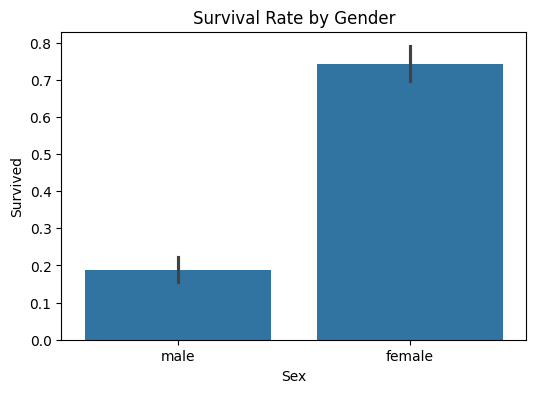

In [15]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Sex',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Gender")
plt.show()

### *Insight-*

Female passengers had a significantly higher survival rate than male passengers. This suggests that women were given higher priority during the evacuation process.

#Que 2

***Did passenger class affect survival?***

In [16]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


#Visualization 2
Survival Rate by Passenger Class

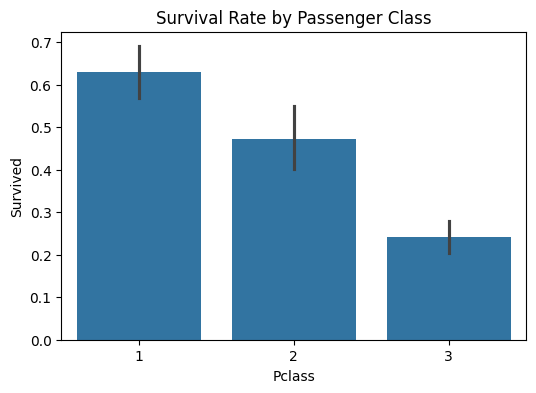

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Pclass',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Passenger Class")
plt.show()

### *Insight-*

Passenger class had a strong impact on survival chances. First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate.

#Que 3
***Survival by Age Group***

In [18]:
bins = [0,12,19,35,60,100]

labels = [
    'Child',
    'Teen',
    'Young Adult',
    'Adult',
    'Senior'
]

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [19]:
df.groupby('AgeGroup')['Survived'].mean()

/tmp/ipykernel_2435/2140893742.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['Survived'].mean()


,Survived
AgeGroup,
Child,0.579710
Teen,0.410526
Young Adult,0.352941
Adult,0.400000
Senior,0.227273


### *Insight-*

Children had the highest survival rate (57.97%), while senior passengers had the lowest survival rate (22.73%).

This suggests that younger passengers were given higher priority during rescue operations.

#Visualization 3
Survival Rate by Age Group

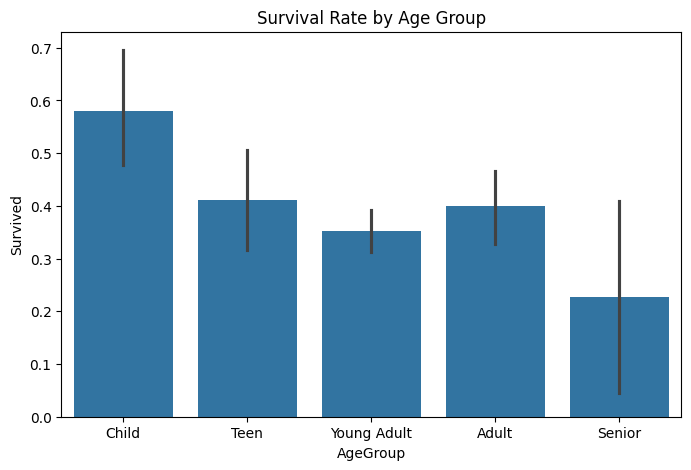

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='AgeGroup',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Age Group")
plt.show()

#Histogram
Distribution og Passenger ages.

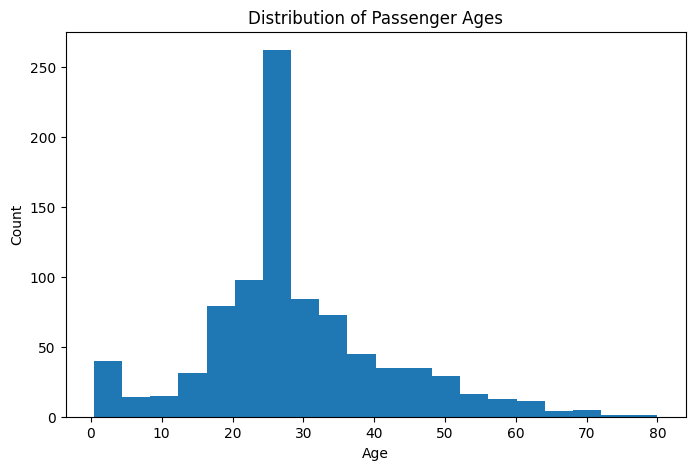

In [21]:
plt.figure(figsize=(8,5))

plt.hist(
    df['Age'],
    bins=20
)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

### *Insight-*

Most passengers were between 20 and 35 years old. The dataset contains passengers from a wide range of age groups, including children and senior citizens.

# Conclusion

1. Female passengers had a significantly higher survival rate than male passengers.

2. First-class passengers had the highest survival rate compared to second and third-class passengers.

3. Children showed the highest survival rate, while senior passengers had the lowest.

4. Data cleaning was necessary to handle missing values in the Age and Embarked columns.

5. Data visualization helped identify important survival patterns within the Titanic dataset.

6. Passenger gender, class, and age all influenced survival chances.